In [ ]:
# Dataset
import kagglehub
techsash_waste_classification_data_path = kagglehub.dataset_download('techsash/waste-classification-data')

print('Data source import complete.')
print(techsash_waste_classification_data_path)


Data source import complete.
/kaggle/input/waste-classification-data


In [ ]:
# Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import numpy as np
import random

In [ ]:
# Settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
DATASET_DIR = techsash_waste_classification_data_path + "/DATASET"

In [ ]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Datasets and Loaders
train_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "TRAIN"), transform=train_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "TEST"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Organic(O) and Recyclable(R)
class_names = train_dataset.classes  # ['O', 'R']

In [ ]:
# FineTune Model Function: DenseNet201
def get_model():
    model = models.densenet201(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False  # Prevents the pre-trained weights from being updated during training.

    # Replace classifier
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 2)  # 2 classes: O, R
    )

    return model.to(device)

In [ ]:
# Get Model
model = get_model()

In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

In [ ]:
# Train Function
def train_model(model, train_loader, test_loader, epochs):
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        running_loss = 0.0

        print(f"\nEpoch {epoch + 1}/{epochs}")
        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

            train_bar.set_postfix({
                'Loss': f'{running_loss / total:.4f}',
                'Acc': f'{correct / total:.4f}'
            })

        acc = correct / total
        train_acc.append(acc)

        # Validation
        model.eval()
        correct = total = 0
        val_bar = tqdm(test_loader, desc="Validating", leave=False)

        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = torch.argmax(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        val_acc.append(val_accuracy)

        print(f"✅ Epoch {epoch+1} Completed - Train Acc: {train_acc[-1]:.4f} | Val Acc: {val_accuracy:.4f}")

    return train_acc, val_acc


In [24]:
# Start Training
train_acc, val_acc = train_model(model, train_loader, test_loader, EPOCHS)


Epoch 1/10


✅ Epoch 1 Completed - Train Acc: 0.9275 | Val Acc: 0.9256

Epoch 2/10


✅ Epoch 2 Completed - Train Acc: 0.9336 | Val Acc: 0.9204

Epoch 3/10


✅ Epoch 3 Completed - Train Acc: 0.9349 | Val Acc: 0.9204

Epoch 4/10


✅ Epoch 4 Completed - Train Acc: 0.9401 | Val Acc: 0.9045

Epoch 5/10


...

✅ Epoch 6 Completed - Train Acc: 0.9432 | Val Acc: 0.9125

Epoch 7/10


✅ Epoch 7 Completed - Train Acc: 0.9461 | Val Acc: 0.9073

Epoch 8/10


✅ Epoch 8 Completed - Train Acc: 0.9477 | Val Acc: 0.9304

Epoch 9/10


✅ Epoch 9 Completed - Train Acc: 0.9507 | Val Acc: 0.9156

Epoch 10/10


✅ Epoch 10 Completed - Train Acc: 0.9515 | Val Acc: 0.9085


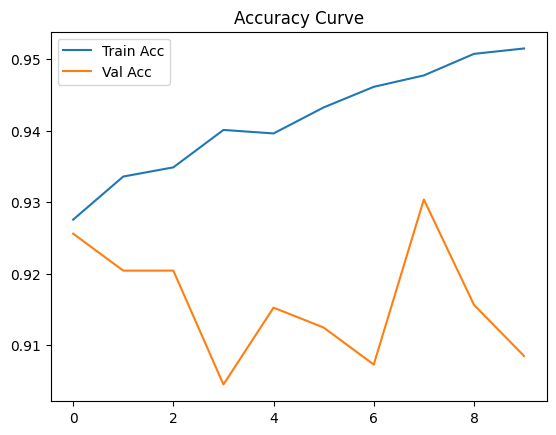

In [25]:
# Plot Accuracy
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [26]:
# Predict Function
def predict_image(model, image_path, class_names):
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    transform = test_transform
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        _, pred = torch.max(output, 1)
        print(f"\033[92mPrediction: This image is -> {class_names[pred.item()]}\033[0m")

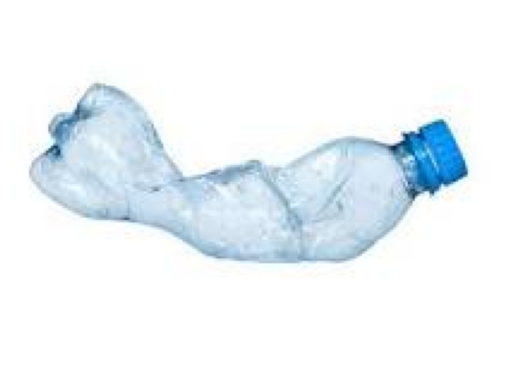

Prediction: This image is -> R


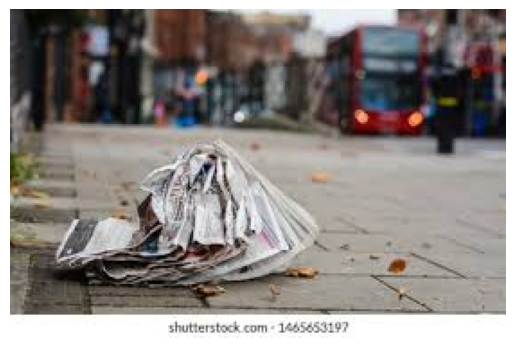

Prediction: This image is -> R


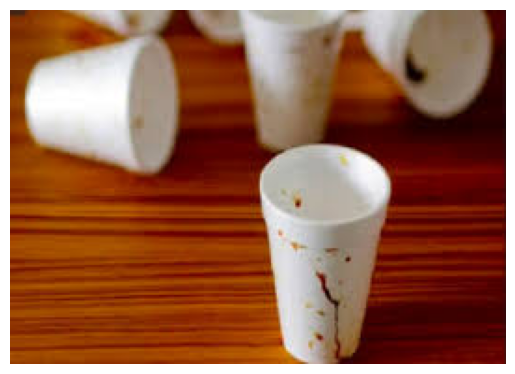

Prediction: This image is -> R


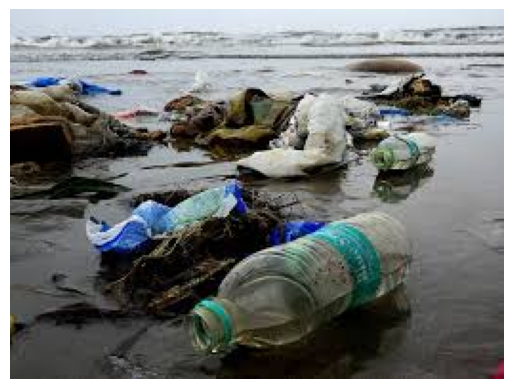

Prediction: This image is -> R


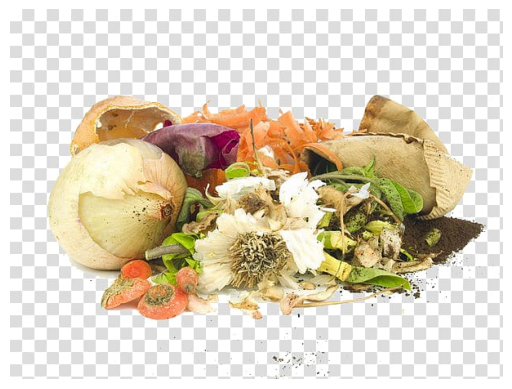

Prediction: This image is -> O


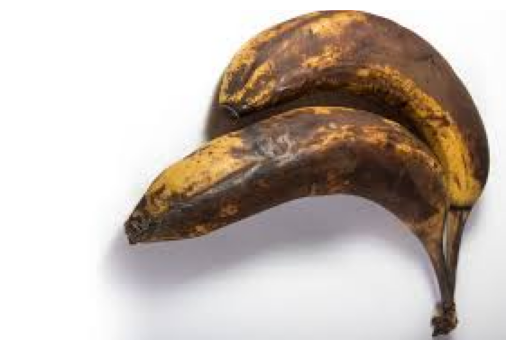

Prediction: This image is -> O


In [34]:
image_paths = [ f'/content/test_image_{i}.png' for i in range(1,7)]

for image_path in image_paths:
    predict_image(model, image_path, class_names)

In [28]:
# Save the model
torch.save(model.state_dict(), 'waste_classifier_with_DenseNet201.pth')
print("Model saved to waste_classifier_with_DenseNet201.pth")

Model saved to waste_classifier_with_DenseNet201.pth


In [29]:
# Download the model
from google.colab import files
files.download('waste_classifier_with_DenseNet201.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>